In [ ]:
# library used to save trained models into the .onnx format
!pip install --upgrade protobuf onnx tf2onnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 32.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.


In [ ]:
# download dataset FER-2013 from kaggle
import os
!mkdir -p ~/.kaggle
!kaggle datasets download -d msambare/fer2013 -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 78.0MB/s]



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras import layers, regularizers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnx

In [ ]:
emotion_map = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 4,
    'sad': 5,
    'surprise': 6
}

class_names = list(emotion_map)
num_classes = len(emotion_map)
img_size = 48
batch_size = 64

print(tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

2.21.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
def load_images(root):

    X, y = [], []
    for name, idx in emotion_map.items():
        folder = os.path.join(root, name)

        for f in os.listdir(folder):
            img = cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE)
            X.append(img)
            y.append(idx)
    X = np.array(X, dtype=np.float32)[..., None] / 255.0     # (N, 48, 48, 1) in [0, 1]
    return X, np.array(y)

train_dir = './data/train'
test_dir = './data/test'

X_train_full, y_train_full = load_images(train_dir)
X_test, y_test = load_images(test_dir)

# validation split from the training set (test set stays untouched)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, stratify=y_train_full, random_state=42
)
print("train:", X_tr.shape, "| val:", X_val.shape, "| test:", X_test.shape)

train: (25838, 48, 48, 1) | val: (2871, 48, 48, 1) | test: (7178, 48, 48, 1)


In [ ]:
# data augmentation for training
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.033), # rotation of about 12 degrees
    layers.RandomTranslation(0.1, 0.1), # around 10% shift
    layers.RandomZoom(0.1), # around 10% zoom
    layers.RandomBrightness(0.1, value_range=(0.0, 1.0)), # brightness jitter
    layers.RandomContrast(0.1), # contrast jitter
])

# makes datasets and augments training
def make_ds(X, y, training):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(10000, seed=42)
    ds = ds.batch(batch_size)
    if training:
        ds = ds.map(lambda a, b: (tf.clip_by_value(augment(a, training=True), 0.0, 1.0), b),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(X_tr, y_tr, training=True)
val_ds = make_ds(X_val, y_val, training=False)
test_ds = make_ds(X_test, y_test, training=False)

In [ ]:
# mini xception architecture
# Arriaga, O., Valdenegro-Toro, M., & Plöger, P. (2017). Real-time Convolutional Neural Networks for Emotion and Gender Classification.
# available at https://arxiv.org/abs/1710.07557
# implementation at https://github.com/oarriaga/face_classification

def mini_xception(input_shape=(img_size, img_size, 1), num_classes=num_classes, l2=0.001):
    reg = regularizers.l2(l2)
    inp = layers.Input(shape=input_shape, name="input")

    x = layers.Conv2D(8, 3, strides=1, use_bias=False, kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(8, 3, strides=1, use_bias=False, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)

    for filters in (16, 32, 64, 128):
        res = layers.Conv2D(filters, 1, strides=2, padding="same", use_bias=False)(x)
        res = layers.BatchNormalization()(res)

        x = layers.SeparableConv2D(filters, 3, padding="same", use_bias=False,
                                   depthwise_regularizer=reg, pointwise_regularizer=reg)(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(filters, 3, padding="same", use_bias=False,
                                   depthwise_regularizer=reg, pointwise_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
        x = layers.Add()([x, res])

    x = layers.Conv2D(num_classes, 3, padding="same", kernel_regularizer=reg)(x)
    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Activation("softmax", name="probabilities")(x)
    return Model(inp, out, name="mini_xception")

model = mini_xception()
model.summary()

Model: "mini_xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 48, 48, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 46, 46, 8) │         72 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 46, 46, 8) │         32 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 46, 46, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 44, 44, 8) │        576 │ activation_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 44, 8) │         32 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 44, 44, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_16 │ (None, 44, 44,    │        200 │ activation_13[0]… │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 44,    │         64 │ separable_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 44, 44,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_17 │ (None, 44, 44,    │        400 │ activation_14[0]… │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 44,    │         64 │ separable_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 22, 22,    │        128 │ activation_13[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 22, 22,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 22, 22,    │         64 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 22, 22,    │          0 │ max_pooling2d_8[… │
│                     │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_18 │ (None, 22, 22,    │        656 │ add_8[0][0]       │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 22, 22,    │        128 │ separable_conv2d

 Total params: 58,423 (228.21 KB)

 Trainable params: 56,951 (222.46 KB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
epochs = 50
steps_per_epoch = int(np.ceil(len(X_tr) / batch_size))

# adjusts learning rate
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=epochs * steps_per_epoch,
    alpha=0.01,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("mini_xception_best.keras", monitor="val_loss",
                                       save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                     restore_best_weights=True),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks)

Epoch 1/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2540 - loss: 2.2575
Epoch 1: val_loss improved from None to 2.19177, saving model to mini_xception_best.keras

Epoch 1: finished saving model to mini_xception_best.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.2838 - loss: 2.1665 - val_accuracy: 0.3002 - val_loss: 2.1918
Epoch 2/50
402/404 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3627 - loss: 1.9508
Epoch 2: val_loss improved from 2.19177 to 1.93594, saving model to mini_xception_best.keras

Epoch 2: finished saving model to mini_xception_best.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.3789 - loss: 1.8897 - val_accuracy: 0.3612 - val_loss: 1.9359
Epoch 3/50
403/404 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4329 - loss: 1.7212
Epoch 3: val_loss improved from 1.93594 to 1.72273, saving model to mini_xception_best.keras

Epoch 3: finished saving model to mini_xception_best.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - 

Test accuracy: 0.612
Classification Report:
              precision    recall  f1-score   support

       angry      0.486     0.596     0.535       958
     disgust      0.543     0.225     0.318       111
        fear      0.461     0.347     0.396      1024
       happy      0.840     0.829     0.835      1774
     neutral      0.553     0.630     0.589      1233
         sad      0.501     0.508     0.505      1247
    surprise      0.736     0.679     0.706       831

    accuracy                          0.612      7178
   macro avg      0.589     0.545     0.555      7178
weighted avg      0.614     0.612     0.610      7178



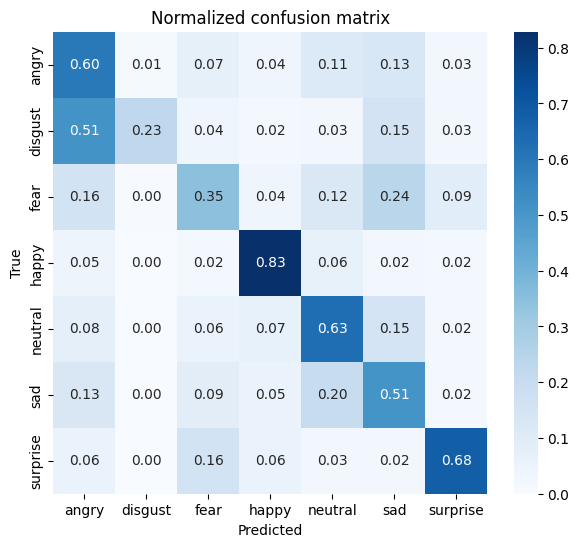

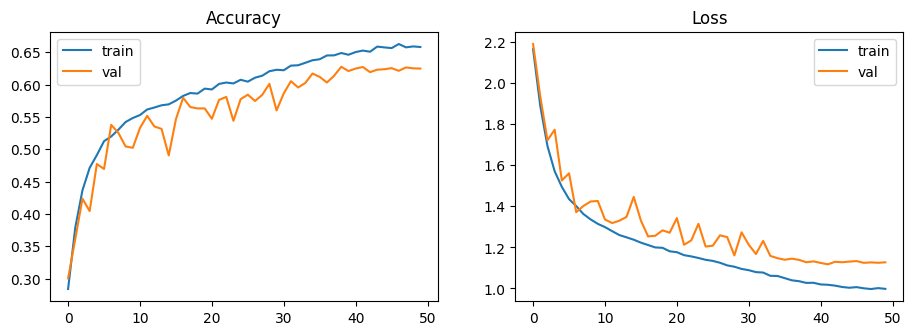

In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print("Test accuracy: %.3f" % test_acc)

y_pred = model.predict(X_test, batch_size=256, verbose=0).argmax(axis=1)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

# plot normalized confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize="true")
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted");
plt.ylabel("True");
plt.title("Normalized confusion matrix")
plt.show()

# training curves
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(history.history["accuracy"], label="train"); ax[0].plot(history.history["val_accuracy"], label="val")
ax[0].set_title("Accuracy"); ax[0].legend()
ax[1].plot(history.history["loss"], label="train"); ax[1].plot(history.history["val_loss"], label="val")
ax[1].set_title("Loss"); ax[1].legend()
plt.show()

In [ ]:
# cell to save trained model to .onnx file
import tf2onnx, onnx

input_signature = [tf.TensorSpec(shape=[None, IMG_SIZE, IMG_SIZE, 1],
                                 dtype=tf.float32, name="input")]

@tf.function
def model_func(input_tensor):
    return model(input_tensor, training=False)

onnx_model, _ = tf2onnx.convert.from_function(
    model_func,
    input_signature=input_signature,
    opset=13,
)

output_path = "mini_xception.onnx"
onnx.save_model(onnx_model, output_path)
print(f"Successfully converted and saved to {output_path}")

Successfully converted and saved to mini_xception.onnx
